### This project focuses on analyzing patient health data, where we will use `KNN Classification` to predict the presence of heart disease (target) based on various medical attributes such as age, sex, cholesterol, blood pressure, and exercise-induced factors.

### Import required Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

### load the `heart.csv` file using pandas

In [6]:
df = pd.read_csv('/content/heart (1).csv')

**View the top 5 rows of the dataset**

In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**Check if there is any kind of null value present in our dataset or not**

In [8]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


### Let's visualize the distribution of patients' ages using a histogram `histplot()`. This will help us understand how ages are spread across the dataset.

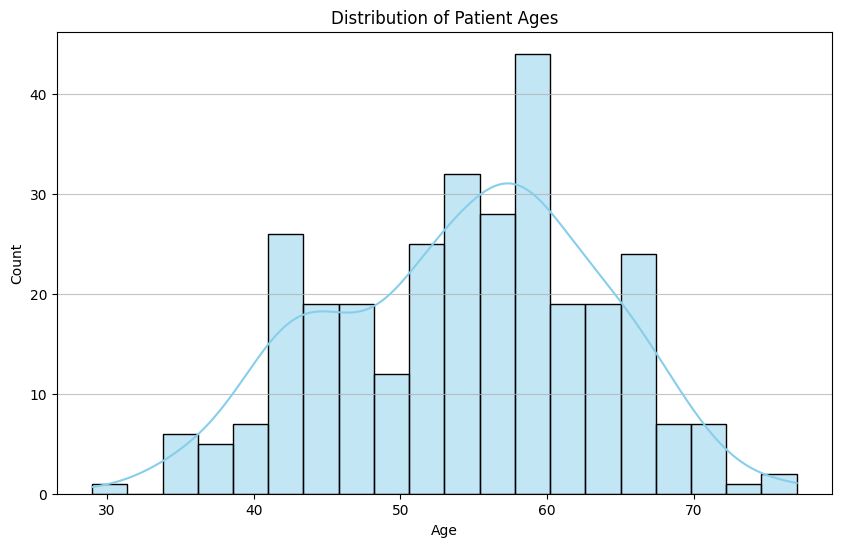

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', kde=True, bins=20, color='skyblue')
plt.title('Distribution of Patient Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### Summary of Age Distribution:

The histogram for 'Distribution of Patient Ages' provides insights into the age demographics of the dataset. Upon reviewing the plot, we can observe:

*   **Central Tendency:** The majority of patients appear to be concentrated in a certain age range, typically around the middle-aged to older adult categories, as indicated by the highest bars.
*   **Spread/Range:** The ages in the dataset span from a minimum to a maximum value, showing the overall age diversity.
*   **Skewness (if any):** The distribution might lean towards younger or older ages. For instance, if the tail is longer on the right side, it suggests a right-skewed distribution with more younger patients, and vice versa.

This distribution is crucial for understanding the patient population and how age might influence the presence of heart disease in subsequent analyses.

### Let's plot a scatter plot of Age vs Cholesterol, with colors representing the presence of heart disease.
This helps us see patterns and relationships between age, cholesterol, and heart disease risk

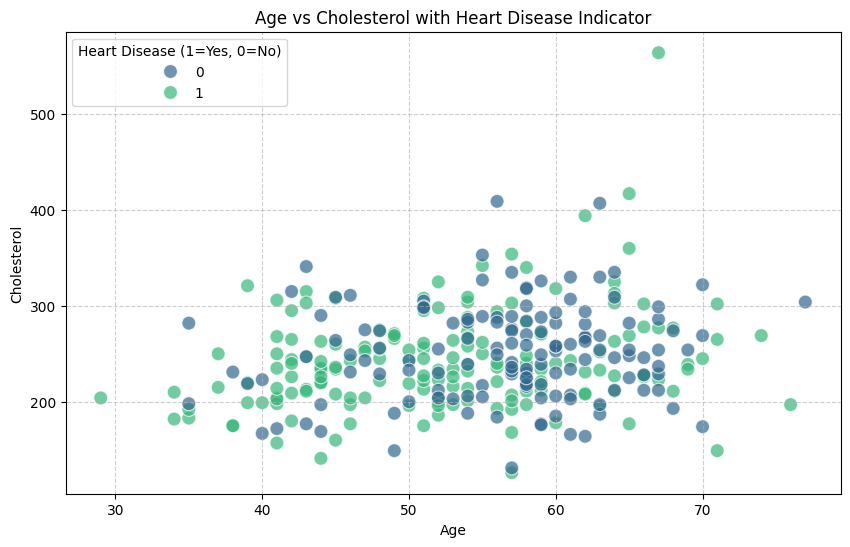

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='chol', hue='target', palette='viridis', s=100, alpha=0.7)
plt.title('Age vs Cholesterol with Heart Disease Indicator')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.legend(title='Heart Disease (1=Yes, 0=No)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Summary of Age vs Cholesterol Scatter Plot:

The scatter plot visualizing 'Age vs Cholesterol with Heart Disease Indicator' helps us understand the relationship between these three variables:

*   **General Trend:** We can observe the distribution of cholesterol levels across different age groups. Look for any general increasing or decreasing trends of cholesterol with age.
*   **Heart Disease Clustering:** The colored points (representing the 'target' variable, 1 for heart disease, 0 for no heart disease) reveal if there are any visible clusters of patients with heart disease in specific age and cholesterol ranges. For example, are older patients with high cholesterol more likely to have heart disease?
*   **Overlap:** Notice the extent of overlap between the two target groups. If there's significant overlap, it suggests that age and cholesterol alone might not be strong discriminators for heart disease, and other factors are at play.

This visualization provides initial insights into how age and cholesterol levels might collectively influence the risk of heart disease, suggesting areas for deeper statistical analysis.

### Correlation Heatmap of All Features in the Dataset
This heatmap helps us quickly identify which features are strongly related to each other and to the target, providing insights into potential risk factors for heart disease.


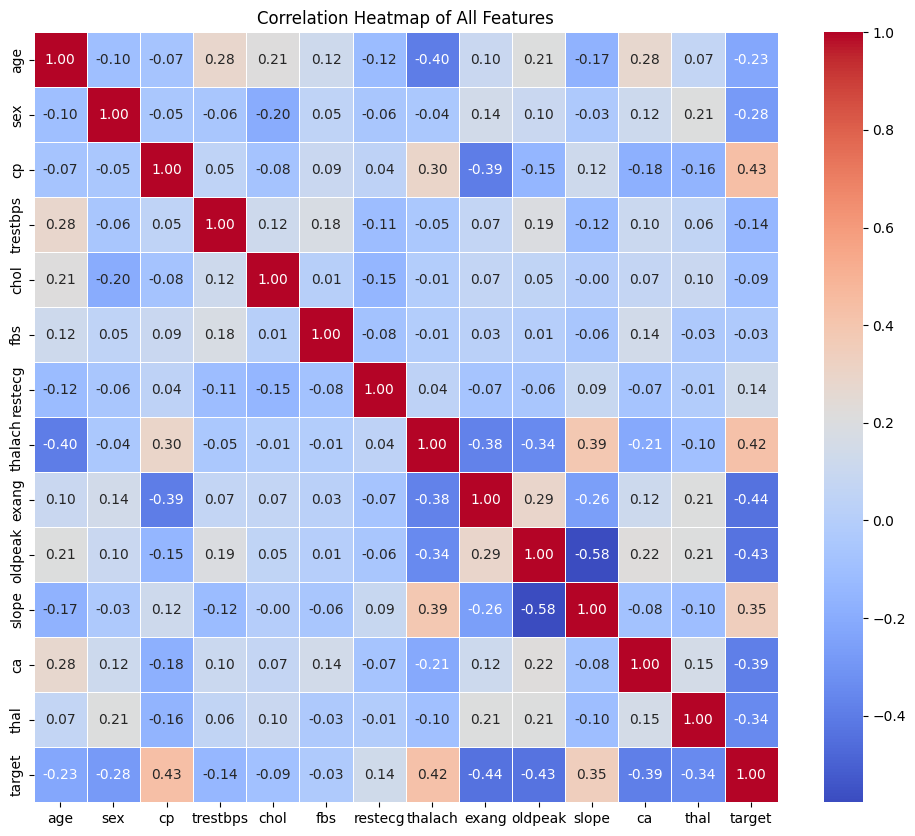

In [11]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of All Features')
plt.show()

#### Summary of Correlation Heatmap:

The correlation heatmap provides a visual representation of the linear relationships between all pairs of features in the dataset. Here's what we can typically observe and infer:

*   **Identifying Key Relationships:** Each cell in the heatmap shows the correlation coefficient between two features. Values range from -1 to +1.
    *   **Positive Correlation (closer to 1):** Indicates that as one feature increases, the other tends to increase as well. For example, if 'age' and 'chol' have a high positive correlation, older patients tend to have higher cholesterol.
    *   **Negative Correlation (closer to -1):** Indicates that as one feature increases, the other tends to decrease. For example, if 'exercise' and 'target' have a negative correlation, more exercise might be associated with a lower chance of heart disease.
    *   **No Correlation (closer to 0):** Suggests little to no linear relationship between the features.

*   **Target Variable Insights:** Pay particular attention to the row or column corresponding to the 'target' variable. This will highlight which features have the strongest positive or negative correlation with heart disease. These features are likely the most influential predictors.

*   **Multicollinearity:** High correlations between independent variables (features other than 'target') can indicate multicollinearity, which might need to be addressed in more advanced modeling techniques.

This heatmap is invaluable for feature selection and understanding the underlying structure of the data before building a predictive model.

In [12]:
correlations = df.corr()['target'].sort_values(ascending=False)
display(correlations)

,target
target,1.000000
cp,0.433798
thalach,0.421741
slope,0.345877
restecg,0.137230
fbs,-0.028046
chol,-0.085239
trestbps,-0.144931
age,-0.225439
sex,-0.280937


#### Features Most Correlated with Target:

Based on the calculated correlation values, the features showing the strongest linear relationships with the `target` variable (presence of heart disease) are:

*   **Strongest Positive Correlations:**
    *   `cp` (chest pain type): 0.433798
    *   `thalach` (maximum heart rate achieved): 0.421741

*   **Strongest Negative Correlations:**
    *   `exang` (exercise induced angina): -0.436757
    *   `oldpeak` (ST depression induced by exercise relative to rest): -0.430696
    *   `ca` (number of major vessels colored by fluoroscopy): -0.391724
    *   `thal` (thallium stress test result): -0.344029

These features are likely to be significant predictors in our heart disease model.

### Separating Features and Target
Here, `X` contains all the independent variables (features) by dropping the `target` column,        
while `y` contains the dependent variable (`target`) that we want to predict.


In [13]:
X = df.drop('target', axis=1)
y = df['target']

### Splitting the Dataset into Training and Testing Sets
We divide the data into training and testing sets using `train_test_split` from `sklearn.model_selection`.  
- `X_train` and `y_train` will be used to train the model.  
- `X_test` and `y_test` will be used to evaluate the model’s performance.  
Here, 33% of the data is reserved for testing, and `random_state=42` ensures reproducibility.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### We have discussed that why Standardization is Needed
KNN relies on distances between data points. If the features are on different scales, some columns may dominate others. Standardizing the features ensures all columns contribute equally to the distance calculations.


In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Creating the KNN Classifier
We are using KNN to predict heart disease. `k` tells the model how many neighbors to check. For now, we start with `k = 4` and will find the best value later.
.


In [16]:
knn = KNeighborsClassifier(n_neighbors=4)

### Training the KNN Model
Here, we train the KNN classifier using the training data (`X_train` and `y_train`) so it can learn patterns to make predictions.


In [17]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4)

### Making Predictions
We use the trained KNN model to predict the target values for the test data (`X_test`). The predictions are stored in `y_pred`.


In [18]:
y_pred = knn.predict(X_test)

### Model Evaluation
After training the model and making predictions, we evaluate its performance using the accuracy scor `(sklearn.metrics)`e to see how well it predicts heart disease.


In [19]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.77


### Finding the Best k Value
Here, we test different values of `k` from 1 to 15 to see which one gives the highest accuracy.  
For each `k`, we train the KNN model, make predictions on the test set, and store the accuracy in the `score` list.


In [20]:
score = []
for i in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    score.append(accuracy_score(y_test, y_pred))

### Visualizing Accuracy for Different k Values
We plot the accuracy scores for `k` values from 1 to 15.  
This helps us see which `k` gives the best performance for our KNN classifier.


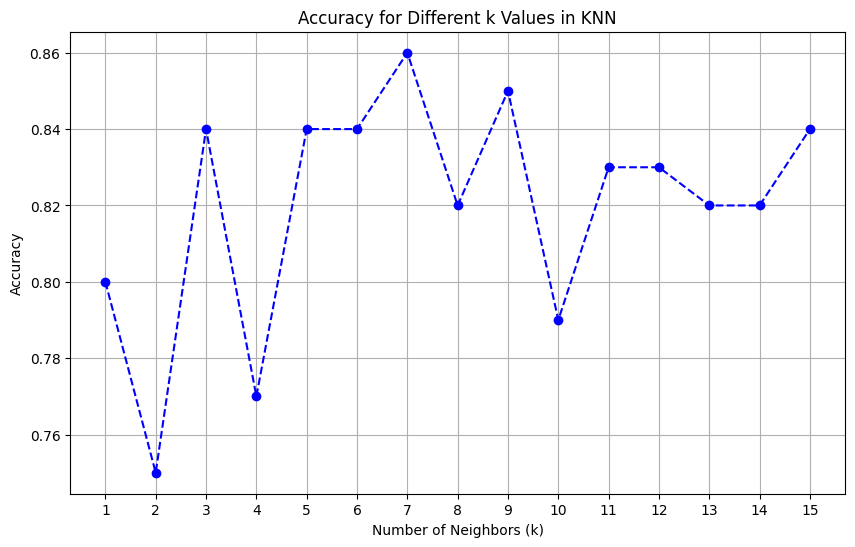

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 16), score, marker='o', linestyle='--', color='blue')
plt.title('Accuracy for Different k Values in KNN')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(range(1, 16))
plt.grid(True)
plt.show()

#### Summary of Accuracy for Different k Values:

The plot titled 'Accuracy for Different k Values in KNN' illustrates how the KNN model's accuracy changes as the number of neighbors (`k`) varies from 1 to 15. This visualization is crucial for hyperparameter tuning.

From the plot, we can observe the following:

*   **Optimal k Value:** The highest accuracy achieved is **0.86**, which occurs when **k = 7**. This indicates that considering 7 nearest neighbors provides the best predictive performance for this dataset.
*   **Performance Trend:** The accuracy fluctuates, initially high, then dipping, and rising again before potentially stabilizing or decreasing. This pattern underscores that the choice of `k` significantly impacts the model's performance.
*   **Interpretation:** Choosing `k=7` suggests that a moderate number of neighbors helps the model generalize well to new, unseen data, avoiding both overfitting (which can happen with very small `k`) and over-smoothing (which can happen with very large `k`).

This analysis guides us in selecting the most effective configuration for our KNN model.

### Re-training the KNN Model with the Optimal k Value (k=7)

Based on our analysis of accuracy for different `k` values, we found that `k=7` yielded the highest accuracy. We will now re-initialize, train, and evaluate the KNN model using this optimal `k` value.

In [22]:
# Re-initializing the KNN classifier with n_neighbors=7
knn_optimal = KNeighborsClassifier(n_neighbors=7)

# Training the model with the optimal k
knn_optimal.fit(X_train, y_train)

# Making predictions with the optimal k
y_pred_optimal = knn_optimal.predict(X_test)

# Evaluating the model with the optimal k
accuracy_optimal = accuracy_score(y_test, y_pred_optimal)
print(f"Model Accuracy with optimal k=7: {accuracy_optimal:.2f}")

Model Accuracy with optimal k=7: 0.86


In [24]:
import pickle

# Define the filename for the pickled model
model_filename = 'knn_optimal_model.pkl'

# Save the trained model to a .pkl file
with open(model_filename, 'wb') as file:
    pickle.dump(knn_optimal, file)

print(f"Model successfully saved to '{model_filename}'")

Model successfully saved to 'knn_optimal_model.pkl'
